# Analysis After

In [15]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import OrdinalEncoder
from imblearn.over_sampling import SMOTENC

in_path  = r"D:\Thesis\mentaldata\mentaldataset_clean.csv"
out_path = r"D:\Thesis\mentaldata\mentaldataset_smote.csv"
target_col = "intent_to_quit"

desired_counts = {3: 30, 5: 45}

allowed_values = {
    "nicotine_use": [1, 5],
    "dietary_habit": [1, 3, 5],
    "sleep_duration": [1, 3, 5],
    "anxiety": [1, 5],
    "depression": [1, 5],
    "self_harm": [1, 5],
    "family_history": [1, 3, 5],
    "work_hours": [1, 2, 3, 4, 5],

    "AP1": [1, 2, 3, 4, 5], "AP2": [1, 2, 3, 4, 5], "AP3": [1, 2, 3, 4, 5], "AP4": [1, 2, 3, 4, 5],
    "FS1": [1, 2, 3, 4, 5], "FS2": [1, 2, 3, 4, 5], "FS3": [1, 2, 3, 4, 5],
    "FP1": [1, 2, 3, 4, 5], "FP2": [1, 2, 3, 4, 5],
    "SS1": [1, 2, 3, 4, 5], "SS2": [1, 2, 3, 4, 5], "SS3": [1, 2, 3, 4, 5],
}


def snap_to_allowed(col_vals: np.ndarray, allowed_list):
    """Snap each value to the nearest allowed value."""
    allowed = np.array(allowed_list, dtype=float)
    v = col_vals.astype(float).reshape(-1, 1)
    idx = np.abs(v - allowed.reshape(1, -1)).argmin(axis=1)
    return allowed[idx].astype(int)


df = pd.read_csv(in_path)

if target_col not in df.columns:
    raise ValueError(f"Missing target column: {target_col}")

# Drop rows with missing y (SMOTE cannot handle NaN in y)
df0 = df.loc[~pd.isna(df[target_col])].copy()

y_raw = pd.to_numeric(df0[target_col], errors="coerce")
df0 = df0.loc[~y_raw.isna()].copy()
df0[target_col] = y_raw.loc[df0.index].astype(int)


X = df0.drop(columns=[target_col]).copy()
y = df0[target_col].astype(int)

# Identify categorical (object) vs numeric
cat_cols = [c for c in X.columns if X[c].dtype == "object" or str(X[c].dtype) == "category"]
num_cols = [c for c in X.columns if c not in cat_cols]

print("cat_cols:", cat_cols)
print("counts_before:\n", y.value_counts().sort_index())


for c in cat_cols:
    X[c] = X[c].fillna("Missing").astype(str)

# Numeric: coerce to numeric + fill missing with median (or 0)
for c in num_cols:
    X[c] = pd.to_numeric(X[c], errors="coerce")
    if X[c].isna().any():
        med = X[c].median()
        if pd.isna(med):
            med = 0
        X[c] = X[c].fillna(med)


if len(cat_cols) > 0:
    enc = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
    X_cat_enc = enc.fit_transform(X[cat_cols])
else:
    enc = None
    X_cat_enc = np.empty((len(X), 0))

X_num = X[num_cols].to_numpy(dtype=float)
X_enc = np.hstack([X_num, X_cat_enc])

cat_idx = list(range(len(num_cols), len(num_cols) + len(cat_cols)))

# Build sampling strategy
counts = y.value_counts()
sampling_strategy = {}
for cls, tgt in desired_counts.items():
    cur = int(counts.get(cls, 0))
    if cur == 0:
        raise ValueError(f"Class {cls} has 0 samples -> cannot SMOTE to {tgt}.")
    if cur < tgt:
        sampling_strategy[cls] = tgt

if not sampling_strategy:
    raise ValueError(f"No class needs oversampling. Current counts:\n{counts.sort_index()}")

min_cls_count = min(int(counts[c]) for c in sampling_strategy.keys())
k_neighbors = min(5, max(1, min_cls_count - 1))

smote = SMOTENC(
    categorical_features=cat_idx,
    sampling_strategy=sampling_strategy,
    k_neighbors=k_neighbors,
    random_state=42,
)

X_res, y_res = smote.fit_resample(X_enc, y.to_numpy())

X_num_res = X_res[:, :len(num_cols)]
X_cat_res = X_res[:, len(num_cols):]

# For numeric columns: round + clip to original min/max, then snap to allowed set (if defined)
mins = df0[num_cols].apply(pd.to_numeric, errors="coerce").min()
maxs = df0[num_cols].apply(pd.to_numeric, errors="coerce").max()

X_num_res_int = np.zeros_like(X_num_res, dtype=int)
for i, col in enumerate(num_cols):
    v = np.rint(X_num_res[:, i])

    # clip to original range if possible
    lo = mins.get(col, np.nan)
    hi = maxs.get(col, np.nan)
    if not (pd.isna(lo) or pd.isna(hi)):
        v = np.clip(v, lo, hi)

    # enforce allowed discrete values if provided
    if col in allowed_values:
        v = snap_to_allowed(v, allowed_values[col])
    else:
        v = v.astype(int)

    X_num_res_int[:, i] = v

df_num = pd.DataFrame(X_num_res_int, columns=num_cols)

# Decode categoricals back to labels
if len(cat_cols) > 0:
    X_cat_int = np.rint(X_cat_res).astype(int)
    X_cat_lbl = enc.inverse_transform(X_cat_int)
    df_cat = pd.DataFrame(X_cat_lbl, columns=cat_cols)
    df_smote = pd.concat([df_num, df_cat], axis=1)[X.columns]
else:
    df_smote = df_num[X.columns].copy()

df_smote[target_col] = y_res.astype(int)

print("counts_after:\n", df_smote[target_col].value_counts().sort_index())

# Validate allowed values (only for columns that exist)
for col, allowed in allowed_values.items():
    if col in df_smote.columns:
        bad = set(pd.Series(df_smote[col]).dropna().unique()) - set(allowed)
        if bad:
            print("WARNING:", col, "has invalid values:", sorted(list(bad)))

df_smote.to_csv(out_path, index=False, encoding="utf-8")

cat_cols: ['gender', 'age', 'living_situation']
counts_before:
 intent_to_quit
1    100
3      9
5     15
Name: count, dtype: int64
counts_after:
 intent_to_quit
1    100
3     30
5     45
Name: count, dtype: int64


In [16]:
df_smote.dtypes

for col in ["gender", "age", "study_year", "work_hours", "nicotine_use", "short_term_memory", "anxiety", "depression","self_harm","intent_to_quit"]:
    print(col)
    print(df_smote[col].value_counts(dropna=False))
    print("-----")

gender
gender
Male                 127
Female                44
Prefer not to say      4
Name: count, dtype: int64
-----
age
age
18-19    98
20-22    52
23+      25
Name: count, dtype: int64
-----
study_year
study_year
1    62
4    59
2    36
3    18
Name: count, dtype: int64
-----
work_hours
work_hours
1    110
2     36
3     14
5     11
4      4
Name: count, dtype: int64
-----
nicotine_use
nicotine_use
1    165
5     10
Name: count, dtype: int64
-----
short_term_memory
short_term_memory
4    77
3    53
2    17
5    17
1    11
Name: count, dtype: int64
-----
anxiety
anxiety
5    122
1     53
Name: count, dtype: int64
-----
depression
depression
1    97
5    78
Name: count, dtype: int64
-----
self_harm
self_harm
1    138
5     37
Name: count, dtype: int64
-----
intent_to_quit
intent_to_quit
1    100
5     45
3     30
Name: count, dtype: int64
-----


In [17]:
df_smote.describe()

,study_year,dietary_habit,nicotine_use,work_hours,AP1,AP2,AP3,AP4,FS1,FS2,...,SS1,SS2,SS3,sleep_duration,anxiety,depression,short_term_memory,family_history,self_harm,intent_to_quit
count,175.00,175.00,175.00,175.00,175.00,175.00,175.00,175.00,175.00,175.00,...,175.00,175.00,175.00,175.00,175.00,175.00,175.00,175.00,175.00,175.00
mean,2.42,2.67,1.23,1.69,3.22,3.69,3.97,3.42,3.14,2.89,...,3.05,2.54,2.98,2.01,3.79,2.78,3.41,1.97,1.85,2.37
std,1.28,1.03,0.93,1.13,0.95,1.17,0.99,1.14,1.06,1.06,...,1.08,1.07,1.12,1.15,1.84,1.99,1.01,1.30,1.64,1.71
min,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,...,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
25%,1.00,3.00,1.00,1.00,3.00,3.00,3.00,3.00,3.00,2.00,...,2.00,2.00,2.00,1.00,1.00,1.00,3.00,1.00,1.00,1.00
50%,2.00,3.00,1.00,1.00,3.00,4.00,4.00,4.00,3.00,3.00,...,3.00,2.00,3.00,1.00,5.00,1.00,4.00,1.00,1.00,1.00
75%,4.00,3.00,1.00,2.00,4.00,5.00,5.00,4.00,4.00,3.00,...,4.00,3.00,4.00,3.00,5.00,5.00,4.00,3.00,1.00,5.00
max,4.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00,...,5.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00


In [18]:
import numpy as np
import pandas as pd

# Ham tinh Cronbach alpha cho mot nhom item
def cronbach_alpha(df_items: pd.DataFrame) -> float:
    # Bo cac dong bi missing trong cac item
    df = df_items.dropna(axis=0, how="any")

    # Chuyen sang numpy
    data = df.to_numpy(dtype=float)

    # So item
    k = data.shape[1]
    if k < 2:
        raise ValueError("Need at least 2 items to compute Cronbach alpha")

    # Phuong sai tung item
    item_var = data.var(axis=0, ddof=1)

    # Tong diem moi nguoi
    total_scores = data.sum(axis=1)

    # Phuong sai tong diem
    total_var = total_scores.var(ddof=1)

    # Cong thuc Cronbach alpha
    alpha = (k / (k - 1.0)) * (1.0 - item_var.sum() / total_var)
    return alpha

# Ham tinh item-total correlation (giong bang Item-Total Statistics trong SPSS)
def item_total_correlation(df_items: pd.DataFrame) -> pd.Series:
    df = df_items.dropna(axis=0, how="any")
    corrs = {}

    for col in df.columns:
        # Tong cac item con lai
        total_others = df.drop(columns=[col]).sum(axis=1)
        # Corr giua item va tong cac item con lai
        corrs[col] = df[col].corr(total_others)

    return pd.Series(corrs, name="item_total_corr")



scales = {
    "AcademicPressure": ["AP1", "AP2", "AP3", "AP4"],
    "FinancialStress": ["FS1", "FS2", "FS3"],
    "FamilyPressure": ["FP1", "FP2"], 
    "StudySatisfaction": ["SS1", "SS2", "SS3"],
    
    
    
}


for scale_name, cols in scales.items():
    items = df_smote[cols]

    alpha = cronbach_alpha(items)
    itc = item_total_correlation(items)

    print(f"Scale: {scale_name}")
    print(f"  Cronbach alpha: {alpha:.3f}")
    print("  Item-total correlation:")
    print(itc)
    print("-" * 40)

Scale: AcademicPressure
  Cronbach alpha: 0.804
  Item-total correlation:
AP1   0.57
AP2   0.72
AP3   0.54
AP4   0.65
Name: item_total_corr, dtype: float64
----------------------------------------
Scale: FinancialStress
  Cronbach alpha: 0.809
  Item-total correlation:
FS1   0.53
FS2   0.75
FS3   0.70
Name: item_total_corr, dtype: float64
----------------------------------------
Scale: FamilyPressure
  Cronbach alpha: 0.686
  Item-total correlation:
FP1   0.53
FP2   0.53
Name: item_total_corr, dtype: float64
----------------------------------------
Scale: StudySatisfaction
  Cronbach alpha: 0.798
  Item-total correlation:
SS1   0.65
SS2   0.63
SS3   0.65
Name: item_total_corr, dtype: float64
----------------------------------------


In [19]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
df_smote = pd.read_csv(r"D:\Thesis\mentaldata\mentaldataset_smote.csv")

# Indicator section: tu dietary_habit den self_harm
indicator_cols_smote = df_smote.columns[
    df_smote.columns.get_loc("dietary_habit") : df_smote.columns.get_loc("self_harm") + 1
].tolist()
print("Indicator columns:", indicator_cols_smote)

# Mental health: dung trung binh anxiety & depression
df_smote["MH_mean"] = df_smote[["anxiety", "depression"]].mean(axis=1)

# Intent to quit: 0 = khong, 1 = co (3 hoac 5)
df_smote["IntentQuit_bin"] = (
    df_smote["intent_to_quit"].replace({1: 0, 3: 1, 5: 1}).astype("int64")
)

# X cho tat ca phan tich (indicator section)
X_smote = df_smote[indicator_cols_smote].copy()
# Scale X
scaler_smote = StandardScaler()
X_scaled_smote = scaler_smote.fit_transform(X_smote)

# y cho tung bai toan
y_mh_smote   = df_smote["MH_mean"]
y_quit_smote = df_smote["IntentQuit_bin"]

print("X shape:", X_smote.shape)
print("y_mh shape:", y_mh_smote.shape)
print("y_quit value counts:\n", y_quit_smote.value_counts())

df_smote.to_csv("df_smote_with_MH_Intent.csv", index=False, encoding="utf-8")

Indicator columns: ['dietary_habit', 'nicotine_use', 'work_hours', 'AP1', 'AP2', 'AP3', 'AP4', 'FS1', 'FS2', 'FS3', 'FP1', 'FP2', 'SS1', 'SS2', 'SS3', 'sleep_duration', 'anxiety', 'depression', 'short_term_memory', 'family_history', 'self_harm']
X shape: (175, 21)
y_mh shape: (175,)
y_quit value counts:
 IntentQuit_bin
0    100
1     75
Name: count, dtype: int64


In [20]:
from sklearn.cluster import KMeans
import numpy as np

kmeans_smote = KMeans(n_clusters=3, random_state=42, n_init=10)
df_smote["cluster_k3"] = kmeans_smote.fit_predict(X_scaled_smote)

# So luong tung cum
cluster_counts_smote = df_smote["cluster_k3"].value_counts().sort_index()
print("Cluster sizes:")
print(cluster_counts_smote)


centers_scaled_smote = kmeans_smote.cluster_centers_
centers_orig_smote = scaler_smote.inverse_transform(centers_scaled_smote)
cluster_centers_orig_smote = pd.DataFrame(
    centers_orig_smote,
    columns=indicator_cols_smote
)
cluster_centers_orig_smote.index.name = "cluster"
print("\nCluster centers (original scale):")
print(cluster_centers_orig_smote.round(2))

# cluster_counts.to_csv("kmeans_cluster_sizes_k3.csv", header=["count"])
cluster_centers_orig_smote.round(2).to_csv("kmeans_cluster_centers_k3_smote.csv")

Cluster sizes:
cluster_k3
0    29
1    60
2    86
Name: count, dtype: int64

Cluster centers (original scale):
         dietary_habit  nicotine_use  work_hours  AP1  AP2  AP3  AP4  FS1  \
cluster                                                                     
0                 2.24          1.14        1.34 2.55 2.69 3.14 2.48 2.90   
1                 2.43          1.33        1.88 2.80 3.22 3.75 2.98 3.03   
2                 2.98          1.19        1.66 3.73 4.36 4.40 4.05 3.30   

         FS2  FS3  ...  FP2  SS1  SS2  SS3  sleep_duration  anxiety  \
cluster            ...                                                
0       2.41 2.21  ... 3.45 3.31 3.14 3.48            1.90     4.86   
1       2.72 2.45  ... 2.67 2.38 2.00 2.23            1.67     2.13   
2       3.17 3.05  ... 4.28 3.43 2.72 3.33            2.28     4.58   

         depression  short_term_memory  family_history  self_harm  
cluster                                                            
0          

In [ ]:
from sklearn.decomposition import PCA

pca_smote = PCA(n_components=X_smote.shape[1])
pca_smote.fit(X_scaled_smote)

# Eigenvalue va explained variance
explained = pd.DataFrame({
    "component": [f"PC{i+1}" for i in range(X_smote.shape[1])],
    "eigenvalue": pca_smote.explained_variance_,
    "explained_variance_ratio": pca_smote.explained_variance_ratio_
})
print("PCA explained variance:")
print(explained.head(10))

# explained.to_csv("pca_explained_variance_indicators.csv", index=False)

# Loadings
loadings_smote = pd.DataFrame(
    pca_smote.components_.T,
    index=indicator_cols_smote,
    columns=[f"PC{i+1}" for i in range(X_smote.shape[1])]
)
print("\nPCA loadings (first 5 components):")
print(loadings_smote.iloc[:, :5].round(3))

# loadings_smote.round(3).to_csv("pca_loadings_indicators_smote.csv", index_label="variable")

PCA explained variance:
  component  eigenvalue  explained_variance_ratio
0       PC1        4.11                      0.19
1       PC2        2.66                      0.13
2       PC3        2.03                      0.10
3       PC4        1.90                      0.09
4       PC5        1.47                      0.07
5       PC6        1.46                      0.07
6       PC7        1.00                      0.05
7       PC8        0.80                      0.04
8       PC9        0.78                      0.04
9      PC10        0.67                      0.03

PCA loadings (first 5 components):
                    PC1   PC2   PC3   PC4   PC5
dietary_habit     -0.16 -0.06 -0.15  0.22  0.12
nicotine_use       0.09 -0.05  0.04  0.49  0.19
work_hours         0.06 -0.10  0.20  0.28 -0.33
AP1               -0.28 -0.17 -0.06  0.33 -0.04
AP2               -0.32 -0.25 -0.18  0.15  0.03
AP3               -0.23 -0.27 -0.30 -0.04  0.07
AP4               -0.24 -0.34 -0.11  0.11  0.16
FS1   

In [22]:
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Bo anxiety, depression khoi predictors vi da dung tao MH_mean
predictor_cols_mh_smote = [
    c for c in indicator_cols_smote 
    if c not in ["anxiety", "depression", "self_harm"]
]

X_mh_smote = df_smote[predictor_cols_mh_smote]
X_mh_const_smote = sm.add_constant(X_mh_smote)

model_mh_smote = sm.OLS(y_mh_smote, X_mh_const_smote).fit()
print(model_mh_smote.summary())

coef_mh_smote = model_mh_smote.params.to_frame(name="coef")
# coef_mh_smote.to_csv("linear_reg_indicators_to_MHmean_coefs_smote.csv")

                            OLS Regression Results                            
Dep. Variable:                MH_mean   R-squared:                       0.440
Model:                            OLS   Adj. R-squared:                  0.375
Method:                 Least Squares   F-statistic:                     6.804
Date:                Fri, 09 Jan 2026   Prob (F-statistic):           2.00e-12
Time:                        15:04:51   Log-Likelihood:                -284.01
No. Observations:                 175   AIC:                             606.0
Df Residuals:                     156   BIC:                             666.1
Df Model:                          18                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                -1.0290      0.74

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report

X_train_smote, X_test_smote, y_train_smote, y_test_smote = train_test_split(
    X_scaled_smote, y_quit_smote, test_size=0.3, random_state=42, stratify=y_quit_smote
)

knn_smote = KNeighborsClassifier(n_neighbors=3)
knn_smote.fit(X_train_smote, y_train_smote)

y_pred_smote = knn_smote.predict(X_test_smote)

cm_smote = confusion_matrix(y_test_smote, y_pred_smote)
print("Confusion matrix (KNN) after SMOTE:")
print(cm_smote)

print("\nClassification report (KNN) after SMOTE:")
print(classification_report(y_test_smote, y_pred_smote, digits=3))

cm_df_smote = pd.DataFrame(cm_smote, index=["True_0","True_1"], columns=["Pred_0","Pred_1"])
cm_df_smote.to_csv("knn_confusion_matrix_intentquit_smote.csv")

Confusion matrix (KNN) after SMOTE:
[[20 10]
 [ 1 22]]

Classification report (KNN) after SMOTE:
              precision    recall  f1-score   support

           0      0.952     0.667     0.784        30
           1      0.688     0.957     0.800        23

    accuracy                          0.792        53
   macro avg      0.820     0.812     0.792        53
weighted avg      0.837     0.792     0.791        53



In [24]:
from lazypredict.Supervised import LazyClassifier

clf_smote = LazyClassifier(
    verbose=0,
    ignore_warnings=True,
    custom_metric=None,
    random_state=42
)
models_smote, predictions_smote = clf_smote.fit(X_train_smote, X_test_smote, y_train_smote, y_test_smote)

print("Top models:")
print(models_smote.head(10))

models_smote.to_csv("lazypredict_models_intentquit_smote.csv")

  0%|          | 0/29 [00:00<?, ?it/s]

[LightGBM] [Info] Number of positive: 52, number of negative: 70
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000055 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 104
[LightGBM] [Info] Number of data points in the train set: 122, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.426230 -> initscore=-0.297252
[LightGBM] [Info] Start training from score -0.297252
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best g

In [25]:
# import time
# import numpy as np
# import pandas as pd

# from sklearn.compose import ColumnTransformer, make_column_selector
# from sklearn.pipeline import Pipeline
# from sklearn.impute import SimpleImputer
# from sklearn.preprocessing import StandardScaler, OneHotEncoder
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.metrics import (
#     accuracy_score,
#     balanced_accuracy_score,
#     f1_score,
#     roc_auc_score,
#     confusion_matrix,
#     classification_report,
# )

# # Assumes you already have:
# # X_train_smote, X_test_smote, y_train_smote, y_test_smote

# def _onehot():
#     try:
#         return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
#     except TypeError:
#         return OneHotEncoder(handle_unknown="ignore", sparse=False)

# def build_preprocessor(X):
#     if isinstance(X, pd.DataFrame):
#         num_pipe = Pipeline([
#             ("imputer", SimpleImputer(strategy="mean")),
#             ("scaler", StandardScaler()),
#         ])
#         cat_pipe = Pipeline([
#             ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
#             ("onehot", _onehot()),
#         ])
#         return ColumnTransformer(
#             transformers=[
#                 ("num", num_pipe, make_column_selector(dtype_include=np.number)),
#                 ("cat", cat_pipe, make_column_selector(dtype_exclude=np.number)),
#             ],
#             remainder="drop",
#         )
#     # numpy array -> treat all numeric
#     return Pipeline([
#         ("imputer", SimpleImputer(strategy="mean")),
#         ("scaler", StandardScaler()),
#     ])

# def print_metrics_block(model_name, y_true, y_pred, y_score=None,
#                         label_names=None, report_digits=3, auc_digits=16):
#     print(f"=== {model_name} metrics ===")

#     auc_txt = "nan"
#     if y_score is not None:
#         try:
#             auc = roc_auc_score(y_true, y_score)
#             auc_txt = f"{auc:.{auc_digits}f}"
#         except Exception:
#             auc_txt = "nan"
#     print(f"AUC ROC: {auc_txt}\n")

#     if label_names is None:
#         label_names = {0: "0", 1: "1"}

#     labels = sorted(list(label_names.keys()))
#     cm = confusion_matrix(y_true, y_pred, labels=labels)

#     row_names = [f"True_{k}_{label_names[k]}" for k in labels]
#     col_names = [f"Pred_{k}_{label_names[k]}" for k in labels]
#     cm_df = pd.DataFrame(cm, index=row_names, columns=col_names)

#     print(f"Confusion matrix ({model_name}):")
#     print(cm_df.to_string())
#     print(f"\nClassification report ({model_name}):")
#     print(classification_report(y_true, y_pred, digits=report_digits))

# # ---------------- run ----------------
# t0 = time.time()

# pre = build_preprocessor(X_train_smote)

# rf = RandomForestClassifier(
#     n_estimators=100,
#     random_state=42,
#     n_jobs=-1
# )

# pipe = Pipeline([
#     ("preprocess", pre),
#     ("model", rf),
# ])

# pipe.fit(X_train_smote, y_train_smote)

# y_pred = pipe.predict(X_test_smote)

# y_score = None
# if hasattr(pipe, "predict_proba"):
#     proba = pipe.predict_proba(X_test_smote)
#     if getattr(proba, "ndim", 0) == 2 and proba.shape[1] == 2:
#         y_score = proba[:, 1]

# dt = time.time() - t0

# # Optional: LazyPredict-like summary row with more decimals
# acc = accuracy_score(y_test_smote, y_pred)
# bal_acc = balanced_accuracy_score(y_test_smote, y_pred)
# f1w = f1_score(y_test_smote, y_pred, average="weighted")
# auc = np.nan
# if y_score is not None:
#     try:
#         auc = roc_auc_score(y_test_smote, y_score)
#     except Exception:
#         auc = np.nan

# summary = pd.DataFrame([{
#     "Model": "RandomForestClassifier",
#     "Accuracy": acc,
#     "Balanced Accuracy": bal_acc,
#     "AUC ROC": auc,
#     "F1 Score": f1w,
#     "Time Taken": dt
# }])

# pd.set_option("display.float_format", lambda x: f"{x:.12f}")

# print()  # spacing

# # Screenshot-style block
# print_metrics_block(
#     "RandomForestClassifier",
#     np.asarray(y_test_smote),
#     np.asarray(y_pred),
#     y_score=y_score,
#     label_names={0: "NoQuit", 1: "Quit"},
#     report_digits=3,
#     auc_digits=16
# )


In [26]:
# from sklearn.ensemble import ExtraTreesClassifier
# from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
# import pandas as pd
# import numpy as np

# # 1) Train ExtraTrees
# et_smote = ExtraTreesClassifier(
#     random_state=42,
# )
# et_smote.fit(X_train_smote, y_train_smote)

# # 2) Du doan
# y_pred_et_smote = et_smote.predict(X_test_smote)
# y_proba_et_smote = et_smote.predict_proba(X_test_smote)[:, 1]
# # 3) Metrics tong quat
# print("=== ExtraTreesClassifier metrics ===")
# print("AUC ROC:", roc_auc_score(y_test_smote, y_proba_et_smote))

# cm_et_smote = confusion_matrix(y_test_smote, y_pred_et_smote)
# cm_et_smote_df = pd.DataFrame(
#     cm_et_smote,
#     index=["True_0_NoQuit", "True_1_Quit"],
#     columns=["Pred_0_NoQuit", "Pred_1_Quit"]
# )
# print("\nConfusion matrix (ExtraTrees):")
# print(cm_et_smote_df)

# print("\nClassification report (ExtraTrees):")
# print(classification_report(y_test_smote, y_pred_et_smote, digits=3))



In [27]:
# from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
# from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
# import pandas as pd

# # QDA
# qda = QuadraticDiscriminantAnalysis()
# qda.fit(X_train_smote, y_train_smote)

# y_pred_qda = qda.predict(X_test_smote)
# y_proba_qda = qda.predict_proba(X_test_smote)[:, 1]

# print("\n=== QuadraticDiscriminantAnalysis metrics ===")
# print("AUC ROC:", roc_auc_score(y_test_smote, y_proba_qda))

# cm_qda = confusion_matrix(y_test_smote, y_pred_qda)
# cm_qda_df = pd.DataFrame(
#     cm_qda,
#     index=["True_0_NoQuit", "True_1_Quit"],
#     columns=["Pred_0_NoQuit", "Pred_1_Quit"]
# )

# print("\nConfusion matrix (QDA):")
# print(cm_qda_df)

# print("\nClassification report (QDA):")
# print(classification_report(y_test_smote, y_pred_qda, digits=3))

Saved: models_after_smote.csv


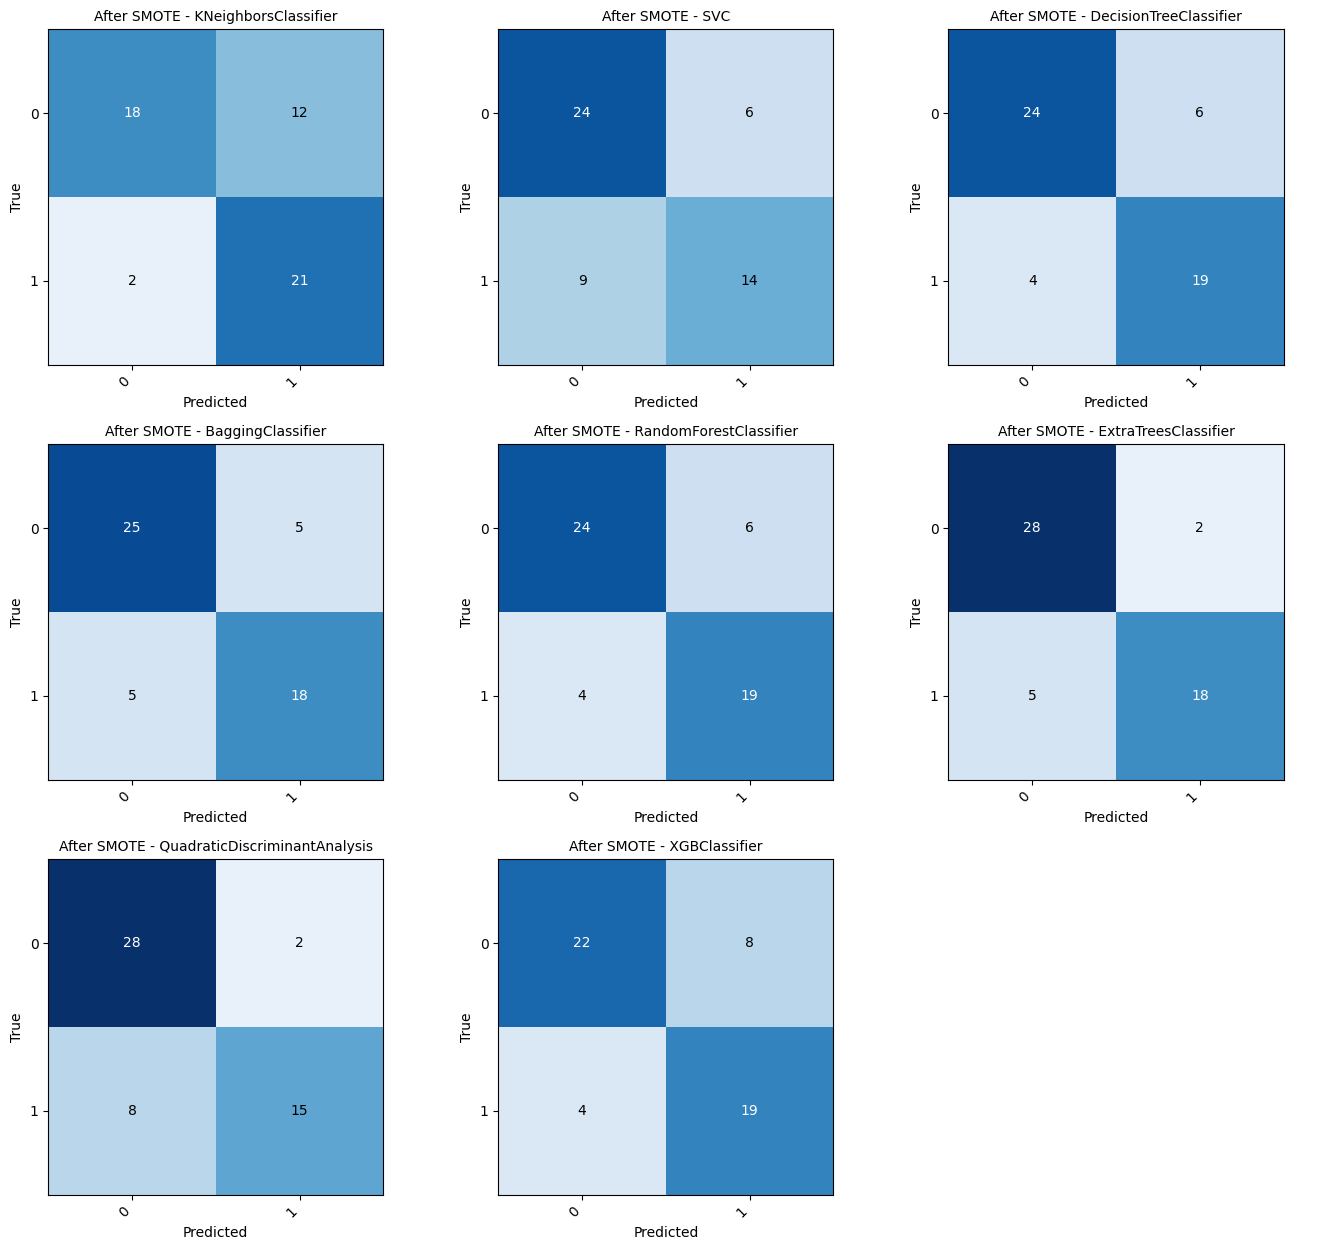

In [28]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, ExtraTreesClassifier
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.base import clone

# XGB optional
try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except Exception:
    HAS_XGB = False


# -----------------------------
# LazyPredict-like preprocessor
# -----------------------------
def _onehot():
    # Lazypredict old/new sklearn compatibility (sparse vs sparse_output)
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


_numeric_transformer = Pipeline(
    steps=[("imputer", SimpleImputer(strategy="mean")), ("scaler", StandardScaler())]
)

_categorical_transformer_low = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
        ("encoding", _onehot()),
    ]
)

_categorical_transformer_high = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
        ("encoding", OrdinalEncoder()),
    ]
)


def get_card_split(df, cols, n=11):
    # Same rule as LazyPredict: high if nunique > n (default n=11)
    if len(cols) == 0:
        return cols, cols
    cond = df[cols].nunique() > n
    return cols[~cond], cols[cond]


def build_lazypredict_preprocessor(X_train):
    # Mimic LazyPredict behavior: if ndarray -> DataFrame, then select_dtypes
    if isinstance(X_train, np.ndarray):
        X_train = pd.DataFrame(X_train)

    numeric_features = X_train.select_dtypes(include=[np.number]).columns
    categorical_features = X_train.select_dtypes(include=["object"]).columns

    cat_low, cat_high = get_card_split(X_train, categorical_features, n=11)

    preprocessor = ColumnTransformer(
        transformers=[
            ("numeric", _numeric_transformer, numeric_features),
            ("categorical_low", _categorical_transformer_low, cat_low),
            ("categorical_high", _categorical_transformer_high, cat_high),
        ]
        # remainder defaults to "drop" (same as LazyPredict)
    )
    return preprocessor


# -----------------------------
# Your model list
# -----------------------------
def build_models(n_classes, random_state=42):
    models = {
        "KNeighborsClassifier": KNeighborsClassifier(),
        "SVC": SVC(kernel="rbf", probability=True, random_state=random_state),
        "DecisionTreeClassifier": DecisionTreeClassifier(random_state=random_state),
        "BaggingClassifier": BaggingClassifier(random_state=random_state),
        "RandomForestClassifier": RandomForestClassifier(random_state=random_state),
        "ExtraTreesClassifier": ExtraTreesClassifier(random_state=random_state),
        "QuadraticDiscriminantAnalysis": QuadraticDiscriminantAnalysis(),
    }

    if HAS_XGB:
        if n_classes == 2:
            models["XGBClassifier"] = XGBClassifier(
                random_state=random_state,
                eval_metric="logloss",
                use_label_encoder=False,
            )
        else:
            models["XGBClassifier"] = XGBClassifier(
                random_state=random_state,
                eval_metric="mlogloss",
                use_label_encoder=False,
            )
    return models


def _scores_for_auc(model, X_test, n_classes):
    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(X_test)
        if n_classes == 2:
            return proba[:, 1]
        return proba
    if hasattr(model, "decision_function"):
        return model.decision_function(X_test)
    return None


def auc_like_lazypredict(y_true, y_pred):
    # LazyPredict uses roc_auc_score(y_test, y_pred) (hard labels), and may fail for multiclass. :contentReference[oaicite:2]{index=2}
    try:
        return roc_auc_score(y_true, y_pred)
    except Exception:
        return np.nan


def plot_confusion_matrices_grid(cms, labels, title_prefix="", cmap="Blues"):
    model_names = list(cms.keys())
    n = len(model_names)
    if n == 0:
        return

    cols = 3
    rows = int(np.ceil(n / cols))

    vmax = max(int(cm.max()) for cm in cms.values()) if cms else 1
    vmax = max(vmax, 1)

    fig, axes = plt.subplots(rows, cols, figsize=(4.6 * cols, 4.2 * rows))
    axes = np.array(axes).reshape(-1)

    for ax, name in zip(axes, model_names):
        cm = cms[name]
        ax.imshow(cm, cmap=cmap, vmin=0, vmax=vmax)

        ax.set_title(f"{title_prefix}{name}", fontsize=10)
        ax.set_xlabel("Predicted")
        ax.set_ylabel("True")

        ax.set_xticks(range(len(labels)))
        ax.set_yticks(range(len(labels)))
        ax.set_xticklabels([str(x) for x in labels], rotation=45, ha="right")
        ax.set_yticklabels([str(x) for x in labels])

        thresh = vmax * 0.55
        for i in range(cm.shape[0]):
            for j in range(cm.shape[1]):
                val = int(cm[i, j])
                ax.text(
                    j, i, str(val),
                    ha="center", va="center",
                    color="white" if val > thresh else "black",
                    fontsize=10
                )

    for ax in axes[len(model_names):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()


def run_models_and_export_csv(
    X_train, X_test, y_train, y_test,
    run_name="",
    out_csv="models_metrics.csv",
    random_state=42,
    cm_cmap="Blues",
    match_lazypredict_for=("RandomForestClassifier", "BaggingClassifier"),
    auc_mode="lazypredict",  # "lazypredict" or "scores"
):
    y_train = np.array(y_train).ravel()
    y_test = np.array(y_test).ravel()

    labels = np.sort(np.unique(np.concatenate([y_train, y_test])))
    n_classes = len(labels)

    models = build_models(n_classes=n_classes, random_state=random_state)

    # Build LazyPredict-like preprocessor ONCE, but clone it per model to avoid shared state
    Xtr = X_train
    Xte = X_test
    if isinstance(Xtr, np.ndarray):
        Xtr = pd.DataFrame(Xtr)
    if isinstance(Xte, np.ndarray):
        # If Xtr is a DataFrame, align columns length-wise
        if isinstance(Xtr, pd.DataFrame):
            Xte = pd.DataFrame(Xte, columns=Xtr.columns)
        else:
            Xte = pd.DataFrame(Xte)

    preprocessor = build_lazypredict_preprocessor(Xtr)

    rows = []
    cms = {}

    for name, model in models.items():
        try:
            t0 = time.perf_counter()

            if name in set(match_lazypredict_for):
                est = clone(model)

                # Match LazyPredict logic: only set random_state if estimator supports it. :contentReference[oaicite:3]{index=3}
                if "random_state" in est.get_params().keys():
                    est.set_params(random_state=random_state)

                pipe = Pipeline(
                    steps=[
                        ("preprocessor", clone(preprocessor)),
                        ("classifier", est),
                    ]
                )
                pipe.fit(Xtr, y_train)
                y_pred = pipe.predict(Xte)

            else:
                # Keep your original behavior for other models
                model.fit(Xtr, y_train)
                y_pred = model.predict(Xte)

            elapsed = time.perf_counter() - t0

            if auc_mode == "lazypredict":
                auc = auc_like_lazypredict(y_test, y_pred)
            else:
                # score/proba style (your previous approach)
                y_score = _scores_for_auc(model, Xte, n_classes)
                if n_classes == 2:
                    auc = roc_auc_score(y_test, y_pred)
                else:
                    auc = roc_auc_score(y_test, y_score, multi_class="ovr", average="weighted") if y_score is not None else np.nan

            row = {
                "Model": name,
                "Accuracy": accuracy_score(y_test, y_pred),
                "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred),
                "AUC ROC": auc,
                "F1 Score": f1_score(y_test, y_pred, average="weighted", zero_division=0),
                "Time Taken": elapsed,
                "Precision": precision_score(y_test, y_pred, average="weighted", zero_division=0),
                "Recall": recall_score(y_test, y_pred, average="weighted", zero_division=0),
            }
            rows.append(row)
            cms[name] = confusion_matrix(y_test, y_pred, labels=labels)

        except Exception as e:
            print(f"[WARN] {name} failed: {e}")
            rows.append({
                "Model": name,
                "Accuracy": np.nan,
                "Balanced Accuracy": np.nan,
                "AUC ROC": np.nan,
                "F1 Score": np.nan,
                "Time Taken": np.nan,
                "Precision": np.nan,
                "Recall": np.nan,
            })

    df = pd.DataFrame(rows)
    df = df.sort_values(["Accuracy", "Balanced Accuracy"], ascending=False).reset_index(drop=True)

    if out_csv:
        df.to_csv(out_csv, index=False)
        print(f"Saved: {out_csv}")

    plot_confusion_matrices_grid(
        cms=cms,
        labels=labels,
        title_prefix=run_name,
        cmap=cm_cmap
    )

    return df, cms


# Example:
# Neu ban muon so sanh dung voi LazyPredict, hay dam bao ban dung CUNG X_test/y_test nhu khi chay LazyPredict.
df_after, cms_after = run_models_and_export_csv(
    X_train_smote, X_test_smote, y_train_smote, y_test_smote,
    run_name="After SMOTE - ",
    out_csv="models_after_smote.csv",
    random_state=42,
    cm_cmap="Blues",
    match_lazypredict_for=("RandomForestClassifier", "BaggingClassifier"),
    auc_mode="lazypredict",
)


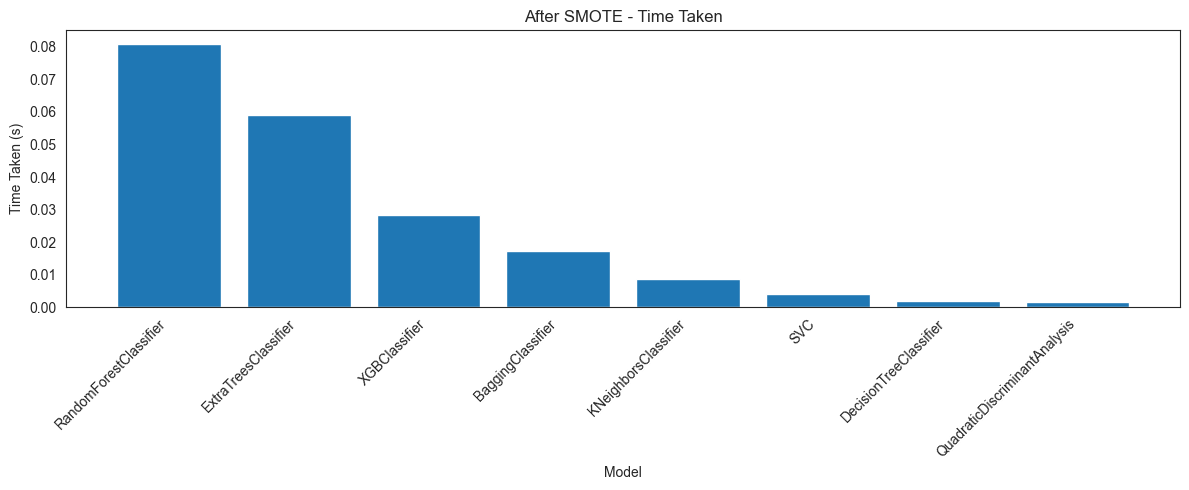

In [39]:
def plot_time_taken_bar(df, title="Time Taken by Model"):
    # Expects columns: "Model", "Time Taken"
    d = df[["Model", "Time Taken"]].copy()
    d["Time Taken"] = pd.to_numeric(d["Time Taken"], errors="coerce")
    d = d.dropna().sort_values("Time Taken", ascending=False)

    plt.figure(figsize=(12, 5))
    plt.bar(d["Model"], d["Time Taken"])
    plt.xlabel("Model")
    plt.ylabel("Time Taken (s)")
    plt.title(title)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


# Example:
# plot_time_taken_bar(df_before_full, title="Before - Time Taken")
plot_time_taken_bar(df_after, title="After SMOTE - Time Taken")

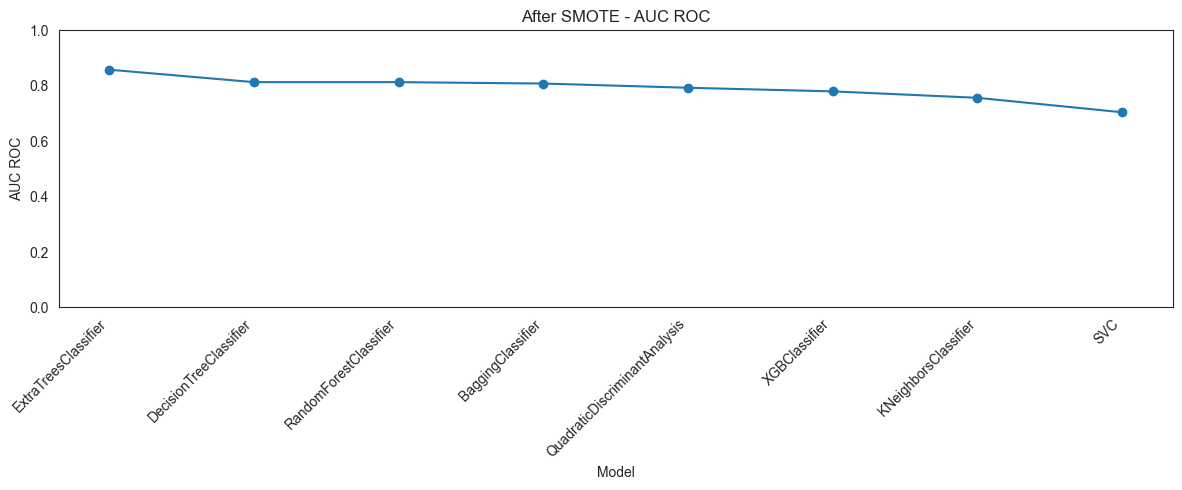

In [40]:
def plot_auc_roc_line(df, title="AUC ROC by Model"):
    # Expects columns: "Model", "AUC ROC"
    d = df[["Model", "AUC ROC"]].copy()
    d["AUC ROC"] = pd.to_numeric(d["AUC ROC"], errors="coerce")
    d = d.dropna().sort_values("AUC ROC", ascending=False)

    plt.figure(figsize=(12, 5))
    plt.plot(d["Model"], d["AUC ROC"], marker="o")
    plt.xlabel("Model")
    plt.ylabel("AUC ROC")
    plt.title(title)
    plt.xticks(rotation=45, ha="right")
    plt.ylim(0, 1)
    plt.tight_layout()
    plt.show()


# Example:
plot_auc_roc_line(df_after, title="After SMOTE - AUC ROC")

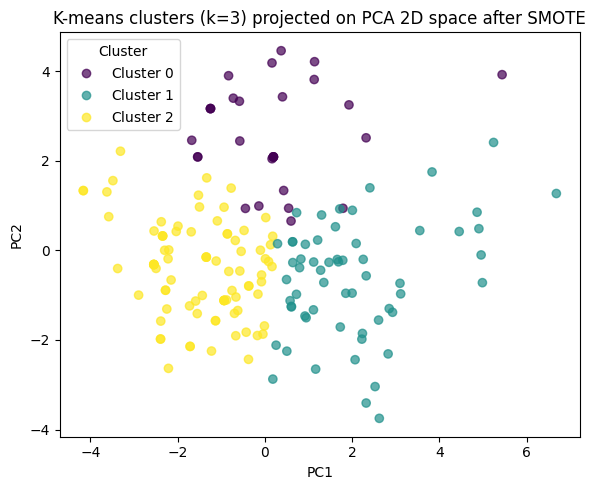

In [29]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# 1) PCA 2 chiều từ X_scaled
pca_2d_smote = PCA(n_components=2)
X_pca2_smote = pca_2d_smote.fit_transform(X_scaled_smote)   # X_scaled bạn đã tạo cho KMeans

# 2) Vẽ scatter, màu = cluster_k3
plt.figure(figsize=(6, 5))
scatter_smote = plt.scatter(
    X_pca2_smote[:, 0], X_pca2_smote[:, 1],
    c=df_smote["cluster_k3"],   # nhãn cụm bạn đã gán
    alpha=0.7
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-means clusters (k=3) projected on PCA 2D space after SMOTE")

# legend cho từng cụm
handles_smote, labels_smote = scatter_smote.legend_elements()
plt.legend(handles_smote, [f"Cluster {l}" for l in labels_smote], title="Cluster")

plt.tight_layout()
plt.show()

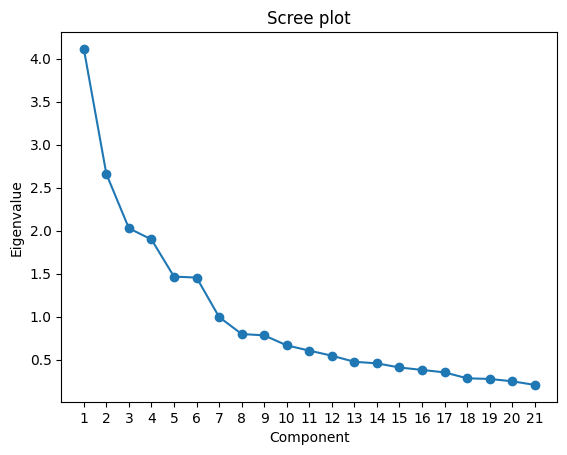

In [30]:
import matplotlib.pyplot as plt
import numpy as np

eigs_smote = pca_smote.explained_variance_ 

plt.plot(range(1, len(eigs_smote)+1), eigs_smote, marker="o")
plt.xlabel("Component")
plt.ylabel("Eigenvalue")
plt.title("Scree plot")
plt.xticks(range(1, len(eigs_smote)+1))
plt.show()

In [31]:
#information gain for intent to quit

import pandas as pd
from sklearn.feature_selection import mutual_info_classif

# 1) Chon X va y
X_ig_smote = df_smote[indicator_cols_smote]         
y_ig_smote = df_smote["IntentQuit_bin"]        

# 2) Tinh mutual information (information gain gan dung)
# discrete_features=True vi cac bien cua ban la thang diem / nhom
mi_smote = mutual_info_classif(
    X_ig_smote,
    y_ig_smote,
    discrete_features=True,
    random_state=42
)

ig_df_smote = pd.DataFrame({
    "feature": indicator_cols_smote,
    "information_gain": mi_smote
})

ig_df_smote = ig_df_smote.sort_values("information_gain", ascending=False).reset_index(drop=True)

print("Information gain for IntentQuit_bin:")
print(ig_df_smote)

Information gain for IntentQuit_bin:
              feature  information_gain
0                 SS1              0.11
1                 SS2              0.09
2          depression              0.07
3   short_term_memory              0.06
4                 SS3              0.06
5                 FP2              0.05
6           self_harm              0.05
7                 FS1              0.05
8             anxiety              0.04
9                 AP3              0.03
10                FS2              0.02
11                AP2              0.02
12                AP1              0.02
13     family_history              0.02
14                AP4              0.02
15         work_hours              0.02
16                FP1              0.01
17                FS3              0.01
18      dietary_habit              0.01
19     sleep_duration              0.00
20       nicotine_use              0.00


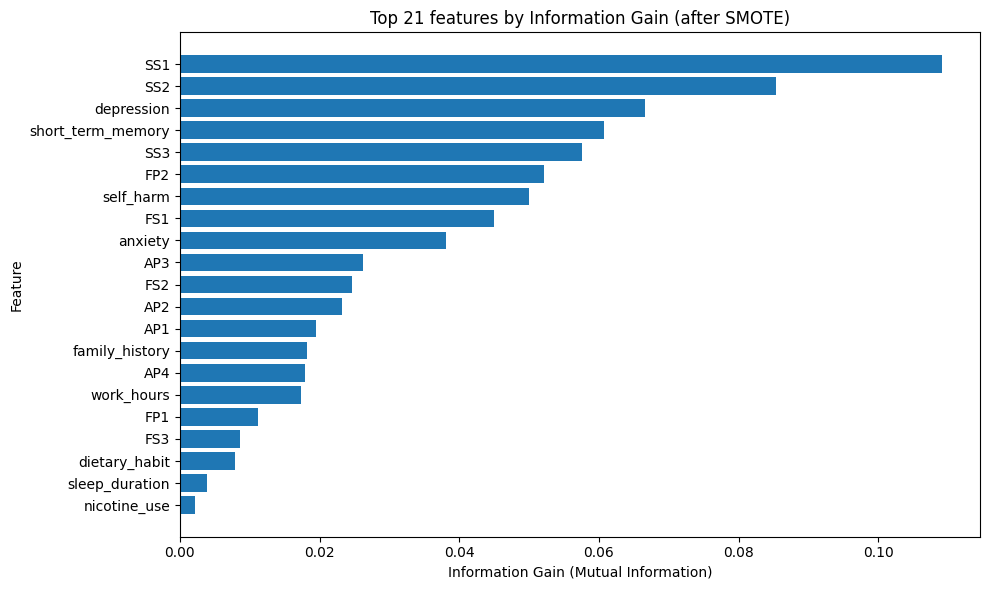

In [32]:
import matplotlib.pyplot as plt

# ig_df_smote da co 2 cot: "feature", "information_gain"
top_n = 21
plot_df = ig_df_smote.head(top_n).copy()

plt.figure(figsize=(10, 6))
plt.barh(plot_df["feature"][::-1], plot_df["information_gain"][::-1])
plt.xlabel("Information Gain (Mutual Information)")
plt.ylabel("Feature")
plt.title(f"Top {top_n} features by Information Gain (after SMOTE)")
plt.tight_layout()
plt.savefig("information_gain_bar_after_smote.png", dpi=300, bbox_inches="tight")
plt.show()

In [33]:
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report

# 1) PCA: lay 5 component dau (ban co the doi so)
pca_svm_smote = PCA(n_components=7, random_state=42)
X_pca_svm_smote = pca_svm_smote.fit_transform(X_scaled_smote)

print("Explained variance ratio:", pca_svm_smote.explained_variance_ratio_.round(3))
print("Total explained:", round(pca_svm_smote.explained_variance_ratio_.sum(), 3))
# 2) Train / test split tren du lieu PCA
X_train_svm_smote, X_test_svm_smote, y_train_svm_smote, y_test_svm_smote = train_test_split(
    X_pca_svm_smote,
    y_quit_smote,
    test_size=0.3,
    random_state=42,
    stratify=y_quit_smote
)

# 3) SVM classifier (kernel RBF)
svm_clf_smote = SVC(
    kernel="rbf",
    probability=True,   # de tinh AUC ROC
    random_state=42
)
svm_clf_smote.fit(X_train_svm_smote, y_train_svm_smote)

# 4) Du doan
y_pred_svm_smote = svm_clf_smote.predict(X_test_svm_smote)
y_prob_svm_smote = svm_clf_smote.predict_proba(X_test_svm_smote)[:, 1]
# 5) Metric danh gia
print("=== SVM on PCA components ===")
print("Accuracy:", round(accuracy_score(y_test_svm_smote, y_pred_svm_smote), 3))
print("AUC ROC:", round(roc_auc_score(y_test_svm_smote, y_prob_svm_smote), 3))
print("\nConfusion matrix (SVM + PCA):")
print(confusion_matrix(y_test_svm_smote, y_pred_svm_smote))

print("\nClassification report (SVM + PCA):")
print(classification_report(y_test_svm_smote, y_pred_svm_smote, digits=3))

Explained variance ratio: [0.195 0.126 0.096 0.09  0.069 0.069 0.047]
Total explained: 0.692
=== SVM on PCA components ===
Accuracy: 0.623
AUC ROC: 0.751

Confusion matrix (SVM + PCA):
[[22  8]
 [12 11]]

Classification report (SVM + PCA):
              precision    recall  f1-score   support

           0      0.647     0.733     0.688        30
           1      0.579     0.478     0.524        23

    accuracy                          0.623        53
   macro avg      0.613     0.606     0.606        53
weighted avg      0.618     0.623     0.616        53



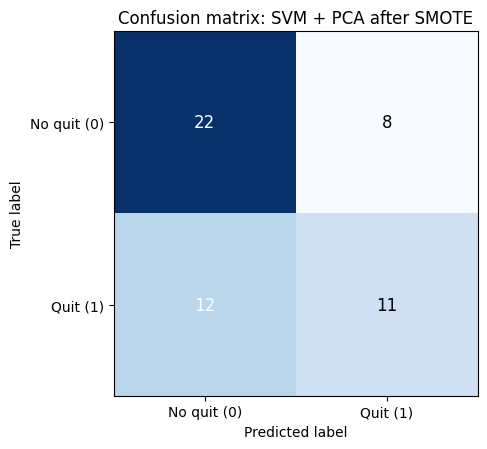

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm_smote = confusion_matrix(y_test_svm_smote, y_pred_svm_smote)

fig, ax = plt.subplots(figsize=(5.2, 4.6))

im = ax.imshow(cm_smote, cmap="Blues")  # doi mau neu muon

thresh = cm_smote.max() / 2.0
for i in range(cm_smote.shape[0]):
    for j in range(cm_smote.shape[1]):
        ax.text(
            j, i, f"{cm_smote[i, j]}",
            ha="center", va="center",
            color="white" if cm_smote[i, j] > thresh else "black",
            fontsize=12
        )

ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["No quit (0)", "Quit (1)"])
ax.set_yticklabels(["No quit (0)", "Quit (1)"])
ax.set_title("Confusion matrix: SVM + PCA after SMOTE")

plt.tight_layout()
plt.show()


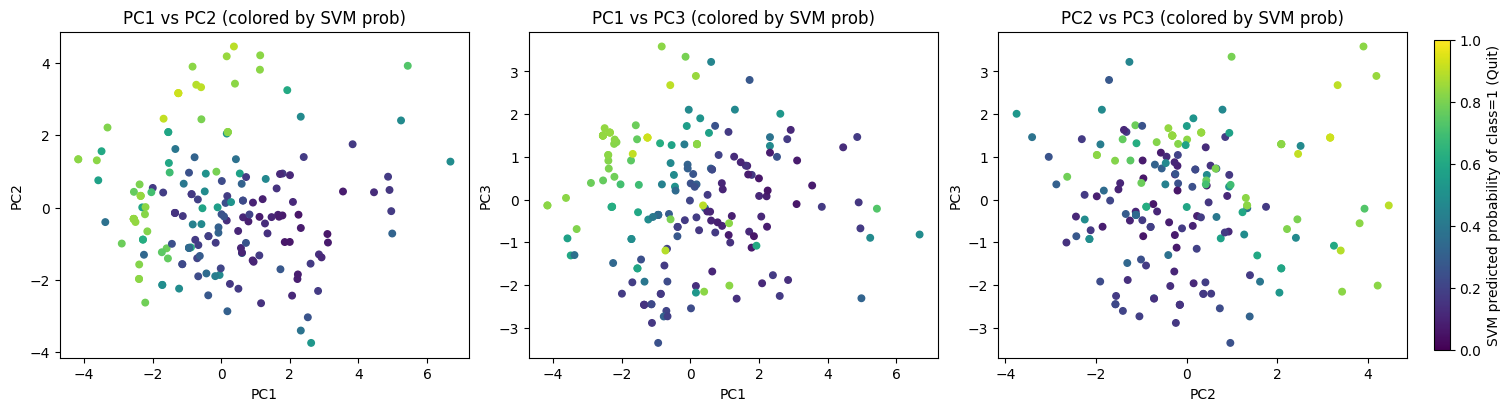

In [35]:
import matplotlib.pyplot as plt
import numpy as np

from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC

# Assumptions:
# - X_scaled_smote: da scale xong (numpy array)
# - y_quit_smote: nhan 0/1 (IntentQuit_bin) tuong ung voi X_scaled_smote

# 1) PCA -> 3 PCs
pca3 = PCA(n_components=3, random_state=42)
X_pca3 = pca3.fit_transform(X_scaled_smote)

# 2) Train/Test split + train SVM tren 3 PCs (de visualization "dung 3 PC" cho ca model)
X_train3, X_test3, y_train3, y_test3 = train_test_split(
    X_pca3,
    y_quit_smote,
    test_size=0.3,
    random_state=42,
    stratify=y_quit_smote
)

svm_clf_3pc = SVC(kernel="rbf", probability=True, random_state=42)
svm_clf_3pc.fit(X_train3, np.array(y_train3).ravel())

# 3) Prob class=1 tren toan bo data (de to mau)
y_prob_all = svm_clf_3pc.predict_proba(X_pca3)[:, 1]

# 4) Ve 3 cap: (PC1,PC2), (PC1,PC3), (PC2,PC3)
pairs = [
    (0, 1, "PC1", "PC2"),
    (0, 2, "PC1", "PC3"),
    (1, 2, "PC2", "PC3"),
]

cmap_name = "viridis"  # thu "plasma", "magma", "coolwarm" neu muon doi mau

fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)

sc = None
for ax, (i, j, xi, yj) in zip(axes, pairs):
    sc = ax.scatter(
        X_pca3[:, i],
        X_pca3[:, j],
        c=y_prob_all,
        s=22,
        cmap=cmap_name,
        vmin=0.0,
        vmax=1.0
    )
    ax.set_xlabel(xi)
    ax.set_ylabel(yj)
    ax.set_title(f"{xi} vs {yj} (colored by SVM prob)")

# 1 colorbar chung cho ca 3 plot
cbar = fig.colorbar(sc, ax=axes, shrink=0.95, pad=0.02)
cbar.set_label("SVM predicted probability of class=1 (Quit)")

plt.show()


In [36]:
import numpy as np
import pandas as pd

print("y true counts:\n", pd.Series(y_quit_smote).value_counts())
print("y pred counts:\n", pd.Series(svm_clf_3pc.predict(X_pca3)).value_counts())

print("prob summary:")
print("min =", y_prob_all.min(), "max =", y_prob_all.max(), "mean =", y_prob_all.mean())
print("p05,p50,p95 =", np.percentile(y_prob_all, [5, 50, 95]))

y true counts:
 IntentQuit_bin
0    100
1     75
Name: count, dtype: int64
y pred counts:
 0    111
1     64
Name: count, dtype: int64
prob summary:
min = 0.058274340217510504 max = 0.9251515892004827 mean = 0.41709903203999066
p05,p50,p95 = [0.0774556  0.33306355 0.843061  ]


Correlation matrix:
                   dietary_habit  nicotine_use  work_hours   AP1   AP2   AP3  \
dietary_habit               1.00          0.13       -0.07  0.24  0.22  0.17   
nicotine_use                0.13          1.00        0.22  0.10 -0.04 -0.09   
work_hours                 -0.07          0.22        1.00  0.09 -0.01 -0.11   
AP1                         0.24          0.10        0.09  1.00  0.56  0.34   
AP2                         0.22         -0.04       -0.01  0.56  1.00  0.54   
AP3                         0.17         -0.09       -0.11  0.34  0.54  1.00   
AP4                         0.17          0.08        0.08  0.50  0.60  0.48   
FS1                         0.07         -0.10        0.16  0.14  0.11  0.05   
FS2                         0.02         -0.11       -0.02  0.13  0.18  0.11   
FS3                         0.04         -0.10       -0.04  0.19  0.23  0.19   
FP1                        -0.04         -0.30       -0.06 -0.05  0.10  0.22   
FP2                 

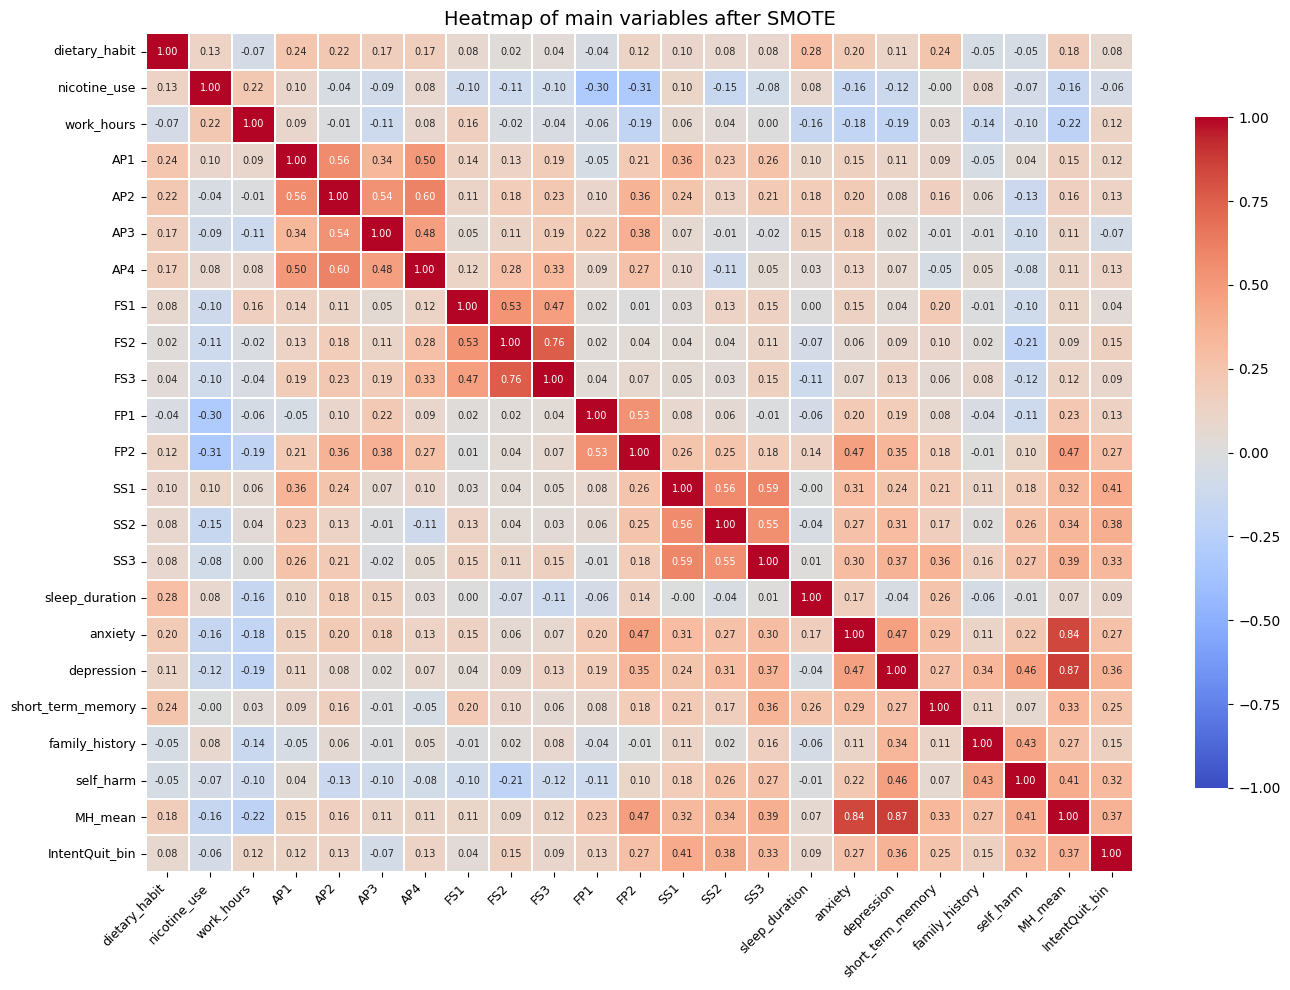

In [37]:
scale_vars_smote = df_smote.select_dtypes(include=["int64", "float64", "Int64"]).columns.tolist()

cols_to_drop = ["study_year", "intent_to_quit"]
scale_vars_smote = [c for c in scale_vars_smote if c not in cols_to_drop]

import matplotlib.pyplot as plt
import seaborn as sns

# 1) Ma tran tuong quan Pearson
corr_smote = df_smote[scale_vars_smote].corr()

print("Correlation matrix:")
print(corr_smote.round(3))


plt.figure(figsize=(14, 10)) 

ax = sns.heatmap(
    corr_smote,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1, vmax=1,
    annot_kws={"size": 7},    
    linewidths=0.3,            
    cbar_kws={"shrink": 0.8}   
)

plt.title("Heatmap of main variables after SMOTE", fontsize=14)


ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)

plt.tight_layout()
plt.savefig("heatmap_mainvars_smote.png", dpi=300, bbox_inches="tight")
plt.show()


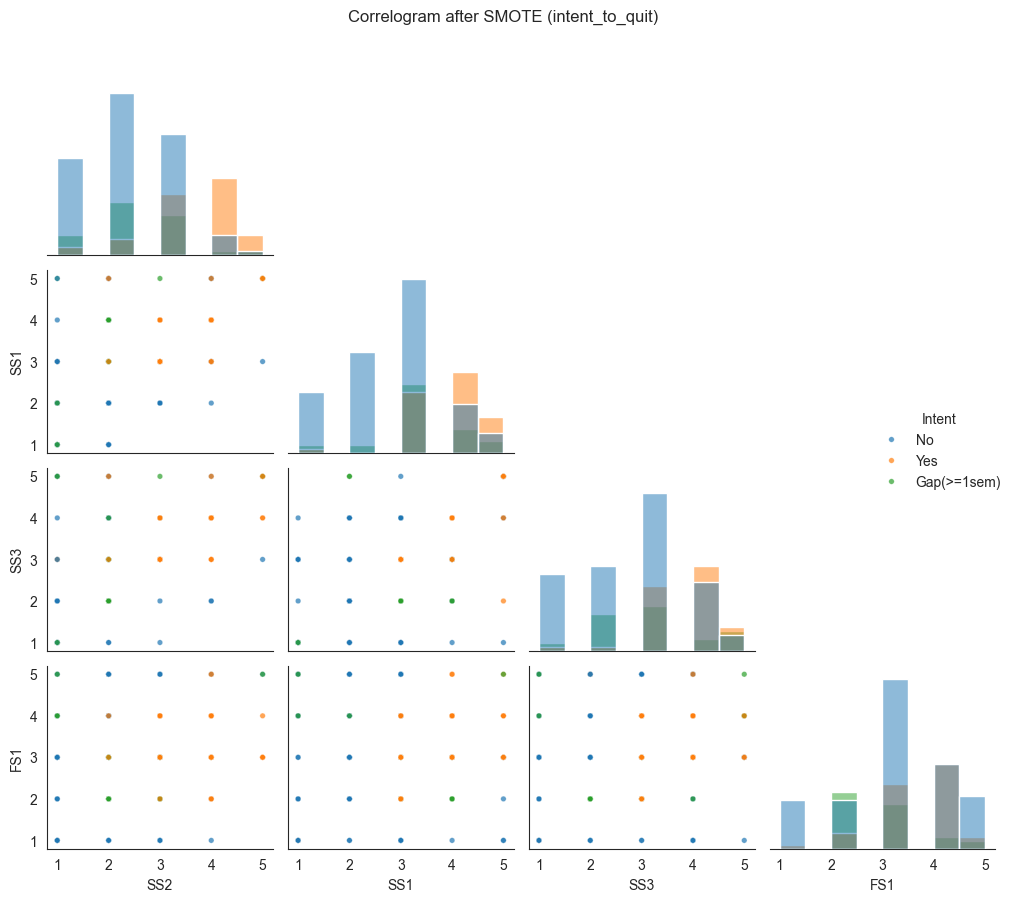

In [38]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_selection import mutual_info_classif

# ========= CHON DATASET =========
# df_plot = df_before   # truoc SMOTE     # sau SMOTE

# ========= CHON TARGET =========
# Neu ban muon ve theo 3 nhom (1,3,5) thi dung intent_to_quit
target_col = "intent_to_quit"

# Neu ban muon ve theo nhi phan (0/1) thi doi sang IntentQuit_bin
# target_col = "IntentQuit_bin"

# ========= CHON CAC FEATURE LIEN QUAN INTENT =========
# Cach 1: neu ban da co list indicator_cols / indicator_cols_smote thi dung no
# feature_cols = indicator_cols           # truoc SMOTE
# feature_cols = indicator_cols_smote     # sau SMOTE

# Cach 2 (an toan): tu dong lay cac cot numeric, bo cac cot khong muon
drop_cols = {"study_year", "MH_mean", "IntentQuit_bin", "intent_to_quit"}
feature_cols = [
    c for c in df_smote.select_dtypes(include=["int64", "float64", "Int64"]).columns
                  if c not in drop_cols
]

# ========= (TU CHON) LAY TOP N FEATURE DE DE NHIN HON =========
# Neu ban muon ve HET TAT CA feature_cols, dat top_n = None
top_n = 4  # doi 8-15 cho de nhin; dat None neu muon full

df_tmp = df_smote[feature_cols + [target_col]].dropna()
X = df_tmp[feature_cols]
y = df_tmp[target_col].astype(int)

if top_n is not None:
    mi = mutual_info_classif(X, y, discrete_features=True, random_state=42)
    mi_s = pd.Series(mi, index=feature_cols).sort_values(ascending=False)
    use_cols = mi_s.head(top_n).index.tolist()
else:
    use_cols = feature_cols

df_pair = df_tmp[use_cols + [target_col]].copy()

# ========= LABEL CHO HUE =========
if target_col == "intent_to_quit":
    label_map = {1: "No", 3: "Gap(>=1sem)", 5: "Yes"}
    df_pair["intent_label"] = df_pair[target_col].map(label_map).fillna(df_pair[target_col].astype(str))
    hue_col = "intent_label"
else:
    label_map = {0: "NoQuit", 1: "Quit"}
    df_pair["intent_label"] = df_pair[target_col].map(label_map).fillna(df_pair[target_col].astype(str))
    hue_col = "intent_label"

# ========= VE PAIR "CORRELOGRAM" =========
sns.set_style("white")

g = sns.PairGrid(
    df_pair,
    vars=use_cols,
    hue=hue_col,
    corner=True,
    height=2.2
)

# Duong cheo: histogram
g.map_diag(sns.histplot, bins=8)

# Tam giac duoi: scatter (cham) + to mau theo intent
g.map_lower(sns.scatterplot, s=16, alpha=0.7)

g.add_legend(title="Intent")

plt.suptitle(f"Correlogram after SMOTE ({target_col})", y=1.02)
plt.tight_layout()
plt.show()
